# 在线泊松采样 Conv1d CSNN

原始窗口来自 `ninapro_data/processed/exerciseA/slide_window`。训练集每次读取样本时重新进行泊松采样，避免模型记忆某一次固定随机实现；测试集使用固定种子物化一次，以保证各 epoch 的测试指标可比较。

泊松率映射、零阶保持和二值时间箱概率与 `src/poisson_spike_encoding.ipynb` 保持一致。模型在每个 SNN 时间步上使用 `Conv1d` 对完整 16 电极通道轴卷积。

按照项目现有训练协议，每个 epoch 在测试集上评估并按测试准确率保存 `best.pt`，因此结果属于 **test-selected checkpoint**。

In [1]:
from pathlib import Path


def find_project_root():
    """从当前目录向上查找项目根目录。"""
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src").is_dir() and (candidate / "ninapro_data").is_dir():
            return candidate
    raise FileNotFoundError("未找到同时包含 src 与 ninapro_data 的项目根目录")


PROJECT_ROOT = find_project_root()

import sys
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = /root/autodl-tmp/NinaPro


## 1. 实验参数

In [2]:
from src.training.config import (
    BATCH_SIZE,
    CHECKPOINT_INTERVAL,
    DETERMINISTIC,
    EPOCHS,
    EVAL_INTERVAL,
    GRADIENT_CLIP,
    LEARNING_RATE,
    MIXED_PRECISION,
    NUM_WORKERS,
    SEED,
    WARMUP_EPOCHS,
    WEIGHT_DECAY,
    print_training_config,
)

ENCODING = "polarity_split"
T = 40
AVAILABLE_ENCODINGS = {
    "offset_128": {"input_channels": 16, "polarity_channels": 1},
    "polarity_split": {"input_channels": 32, "polarity_channels": 2},
}
AVAILABLE_TIME_STEPS = (40, 80, 120)
SOURCE_TIME_STEPS = 40
SOURCE_CHANNELS = 16
WINDOW_SECONDS = 0.2

TEST_ENCODING_SEED = 20260827
TEST_MATERIALIZE_CHUNK_SIZE = 1024
FAST_MODE = True
PREFER_CUPY = True
GPU_RESIDENT_DATA = False

ELECTRODE_CHANNELS = 16
FEATURE_CHANNELS = (32, 64, 128)
NUM_CLASSES = 12
TAU = 2.0
DROPOUT_RATE = 0.3
LEARNABLE_TAU = False

RUN_OVERFIT_CHECK = False
OVERFIT_MAX_STEPS = 500
OVERFIT_TARGET_ACCURACY = 0.99
OVERFIT_SAMPLES_PER_CLASS = 2
RESUME_FROM = None

# 如需实验级差异，请在此行之前覆盖导入值，再打印实际生效配置。
print_training_config(locals())

In [3]:
if ENCODING not in AVAILABLE_ENCODINGS:
    raise ValueError(
        f"ENCODING={ENCODING!r} 不可用，可选值为 {tuple(AVAILABLE_ENCODINGS)}"
    )
if T not in AVAILABLE_TIME_STEPS:
    raise ValueError(
        f"T={T} 没有对应配置，可选值为 {AVAILABLE_TIME_STEPS}"
    )

encoding_config = AVAILABLE_ENCODINGS[ENCODING]
INPUT_CHANNELS = encoding_config["input_channels"]
POLARITY_CHANNELS = encoding_config["polarity_channels"]
DATA_DIR = (
    PROJECT_ROOT / "ninapro_data" / "processed" / "exerciseA" / "slide_window"
)
MODEL_NAME = "NinaProChannelConvCSNN"
NEURON_NAME = "PLIF" if LEARNABLE_TAU else "LIF"
EXPERIMENT_NAME = (
    f"{MODEL_NAME}_{NEURON_NAME}_BATCH_SIZE{BATCH_SIZE}_LR{LEARNING_RATE}"
    f"_FEATURES{'-'.join(map(str, FEATURE_CHANNELS))}"
    f"_DROPOUT{DROPOUT_RATE}_TAU{TAU}_WD{WEIGHT_DECAY}"
)
OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "online_poisson_spikes_csnn"
    / ENCODING
    / f"T_{T}"
    / EXPERIMENT_NAME
)

print(f"ENCODING = {ENCODING}")
print(f"T = {T}, INPUT_CHANNELS = {INPUT_CHANNELS}")
print(f"DATA_DIR = {DATA_DIR}")
print(f"OUTPUT_DIR = {OUTPUT_DIR}")

ENCODING = polarity_split
T = 40, INPUT_CHANNELS = 32
DATA_DIR = /root/autodl-tmp/NinaPro/ninapro_data/processed/exerciseA/slide_window
OUTPUT_DIR = /root/autodl-tmp/NinaPro/outputs/online_poisson_spikes_csnn/polarity_split/T_40/NinaProChannelConvCSNN_LIF_BATCH_SIZE128_LR0.002_FEATURES32-64-128_DROPOUT0.3_TAU2.0_WD0.001


## 2. 随机种子与设备

In [4]:
from src.training import resolve_device, seed_everything

seed_everything(SEED, deterministic=DETERMINISTIC)
DEVICE = resolve_device()
print(f"DEVICE = {DEVICE}")

DEVICE = cuda


## 3. 在线泊松编码

训练数据动态采样；测试数据使用独立固定种子。固定测试样本保存为 `uint8`，在读取时转换为模型需要的浮点张量。

In [5]:
import random
import numpy as np
import torch
from torch.utils.data import Dataset


def target_source_indices(target_steps):
    # 与离线编码文档一致：零阶保持覆盖同一个 200 ms 窗口。
    indices = torch.floor(
        torch.arange(target_steps, dtype=torch.float64)
        * SOURCE_TIME_STEPS
        / target_steps
    ).to(torch.int64)
    return indices.clamp(0, SOURCE_TIME_STEPS - 1)


def poisson_probabilities(raw_features, encoding, target_steps, source_indices):
    if tuple(raw_features.shape[-2:]) != (SOURCE_CHANNELS, SOURCE_TIME_STEPS):
        raise ValueError(
            "原始特征末两维应为 "
            f"({SOURCE_CHANNELS}, {SOURCE_TIME_STEPS})，"
            f"实际为 {tuple(raw_features.shape[-2:])}"
        )
    held = raw_features.index_select(-1, source_indices)

    if encoding == "offset_128":
        shifted = (held + 128.0).clamp(0.0, 255.0)
        rates = shifted * (100.0 / 255.0)
    elif encoding == "polarity_split":
        positive = held.clamp_min(0.0)
        negative = (-held).clamp_min(0.0)
        amplitude = torch.cat((positive, negative), dim=-2)
        amplitude = (amplitude / 64.0).clamp_max(1.0).pow(0.57)
        rates = amplitude * 200.0
    else:
        raise ValueError(f"不支持的编码方法：{encoding}")

    bin_seconds = WINDOW_SECONDS / target_steps
    return -torch.expm1(-rates * bin_seconds)


def sample_binary_spikes(probabilities, generator=None):
    random_values = torch.rand(
        probabilities.shape,
        dtype=probabilities.dtype,
        device=probabilities.device,
        generator=generator,
    )
    return random_values < probabilities


class PoissonSpikeDataset(Dataset):
    """从原始窗口动态采样或提供固定泊松脉冲。"""

    def __init__(
        self,
        raw_dataset,
        encoding,
        target_steps,
        resample,
        fixed_seed=None,
        materialize_chunk_size=1024,
    ):
        self._raw_features = raw_dataset.features
        self.labels = raw_dataset.labels
        self.encoding = encoding
        self.target_steps = target_steps
        self.resample = bool(resample)
        self.source_indices = target_source_indices(target_steps)
        self._fixed_features = None

        if not self.resample:
            if fixed_seed is None:
                raise ValueError("固定采样数据集必须提供 fixed_seed")
            generator = torch.Generator().manual_seed(int(fixed_seed))
            chunks = []
            for start in range(0, len(self), materialize_chunk_size):
                end = min(start + materialize_chunk_size, len(self))
                probabilities = poisson_probabilities(
                    self._raw_features[start:end],
                    self.encoding,
                    self.target_steps,
                    self.source_indices,
                )
                chunks.append(
                    sample_binary_spikes(probabilities, generator).to(torch.uint8)
                )
            self._fixed_features = torch.cat(chunks, dim=0)

    def __len__(self):
        return self.labels.shape[0]

    def __getitem__(self, index):
        if self.resample:
            probabilities = poisson_probabilities(
                self._raw_features[index],
                self.encoding,
                self.target_steps,
                self.source_indices,
            )
            features = sample_binary_spikes(probabilities).to(torch.float32)
        else:
            features = self._fixed_features[index].to(torch.float32)
        return features, self.labels[index]


def seed_worker(worker_id):
    # PyTorch 已为各 worker 设置独立 torch seed；同步其他随机数生成器。
    del worker_id
    worker_seed = torch.initial_seed() % (2**32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)

## 4. 数据集与 DataLoader

In [6]:
from torch.utils.data import DataLoader

from src.data import NinaProWindowDataset

raw_train_dataset = NinaProWindowDataset(DATA_DIR / "train.npz", transform=None)
raw_test_dataset = NinaProWindowDataset(DATA_DIR / "test.npz", transform=None)
train_dataset = PoissonSpikeDataset(
    raw_train_dataset,
    encoding=ENCODING,
    target_steps=T,
    resample=True,
)
test_dataset = PoissonSpikeDataset(
    raw_test_dataset,
    encoding=ENCODING,
    target_steps=T,
    resample=False,
    fixed_seed=TEST_ENCODING_SEED,
    materialize_chunk_size=TEST_MATERIALIZE_CHUNK_SIZE,
)

expected_shape = (INPUT_CHANNELS, T)
train_sample_a, _ = train_dataset[0]
train_sample_b, _ = train_dataset[0]
test_sample_a, _ = test_dataset[0]
test_sample_b, _ = test_dataset[0]
if tuple(train_sample_a.shape) != expected_shape:
    raise ValueError(
        f"训练样本形状应为 {expected_shape}，实际为 {tuple(train_sample_a.shape)}"
    )
if tuple(test_sample_a.shape) != expected_shape:
    raise ValueError(
        f"测试样本形状应为 {expected_shape}，实际为 {tuple(test_sample_a.shape)}"
    )
if torch.equal(train_sample_a, train_sample_b):
    raise RuntimeError("训练样本没有发生在线重采样")
if not torch.equal(test_sample_a, test_sample_b):
    raise RuntimeError("测试样本不是固定泊松实现")

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
    "worker_init_fn": seed_worker,
}
if NUM_WORKERS > 0:
    loader_options["persistent_workers"] = True

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=False,
    generator=torch.Generator().manual_seed(SEED),
    **loader_options,
)
test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    drop_last=False,
    generator=torch.Generator().manual_seed(SEED + 1),
    **loader_options,
)

print(
    f"train={len(train_dataset):,}, test={len(test_dataset):,}, "
    f"shape={expected_shape}"
)
print(
    f"train resampled={not torch.equal(train_sample_a, train_sample_b)}, "
    f"test fixed={torch.equal(test_sample_a, test_sample_b)}"
)

train=17,839, test=8,787, shape=(32, 40)
train resampled=True, test fixed=True


## 5. 通道轴 Conv1d CSNN

In [7]:
from src.models import NinaProCSNN

model = NinaProCSNN(
    input_channels=INPUT_CHANNELS,
    polarity_channels=POLARITY_CHANNELS,
    electrode_channels=ELECTRODE_CHANNELS,
    feature_channels=FEATURE_CHANNELS,
    num_classes=NUM_CLASSES,
    tau=TAU,
    dropout_rate=DROPOUT_RATE,
    learnable_tau=LEARNABLE_TAU,
)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f"parameters = {parameter_count:,}")

NinaProCSNN(
  input_channels=32, input_layout=(2, 16), feature_channels=(32, 64, 128), num_classes=12, tau=2.0, dropout_rate=0.3, learnable_tau=False, step_mode='m', backend='torch', auto_reset=True
  (blocks): ModuleList(
    (0): _ChannelConvSpikeBlock(
      (conv): Conv1d(2, 32, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (normalization): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (neuron): LIFNode(
        v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau=2.0
        (surrogate_function): ATan(alpha=2.0, spiking=True)
      )
      (dropout): Dropout(p=0.3)
    )
    (1): _ChannelConvSpikeBlock(
      (conv): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (normalization): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (neuron): LIFNode(
        v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch,

## 6. 可选的单批次过拟合诊断

In [8]:
import copy

from src.training import overfit_one_batch

diagnostic_history = None
if RUN_OVERFIT_CHECK:
    diagnostic_indices = []
    for class_index in range(NUM_CLASSES):
        class_indices = torch.nonzero(
            train_dataset.labels == class_index,
            as_tuple=False,
        ).flatten()
        diagnostic_indices.extend(
            class_indices[:OVERFIT_SAMPLES_PER_CLASS].tolist()
        )
    diagnostic_samples = [train_dataset[index] for index in diagnostic_indices]
    diagnostic_batch = (
        torch.stack([sample for sample, _ in diagnostic_samples]),
        torch.stack([target for _, target in diagnostic_samples]),
    )
    diagnostic_model = copy.deepcopy(model)
    diagnostic_history = overfit_one_batch(
        diagnostic_model,
        diagnostic_batch,
        max_steps=OVERFIT_MAX_STEPS,
        target_accuracy=OVERFIT_TARGET_ACCURACY,
        learning_rate=LEARNING_RATE,
        gradient_clip=GRADIENT_CLIP,
        device=DEVICE,
    )
    final_diagnostic = diagnostic_history[-1]
    print(
        f"diagnostic steps={len(diagnostic_history)}, "
        f"loss={final_diagnostic['loss']:.4f}, "
        f"accuracy={final_diagnostic['accuracy'] * 100:.2f}%"
    )

## 7. 正式训练

In [9]:
from src.training import fit

CLASS_NAMES = [
    "Index flexion", "Index extension", "Middle flexion", "Middle extension",
    "Ring flexion", "Ring extension", "Little flexion", "Little extension",
    "Thumb adduction", "Thumb abduction", "Thumb flexion", "Thumb extension",
]
experiment_config = {
    "seed": SEED,
    "test_encoding_seed": TEST_ENCODING_SEED,
    "deterministic": DETERMINISTIC,
    "data_dir": str(DATA_DIR),
    "encoding": ENCODING,
    "input_representation": f"online_poisson_{ENCODING}",
    "input_layout_stored": "[B, C, T]",
    "input_layout_model": f"[B, {POLARITY_CHANNELS}, 16, T]",
    "normalization": "none_preserve_binary_spikes",
    "target_time_steps": T,
    "window_seconds": WINDOW_SECONDS,
    "poisson_binary_probability": "1 - exp(-rate_hz * window_seconds / T)",
    "train_poisson_sampling": "resample_each_getitem",
    "test_poisson_sampling": "fixed_materialized",
    "encoding_parameters": {
        "offset_128": {
            "raw_shift": 128.0,
            "amplitude_full_scale": 255.0,
            "max_rate_hz": 100.0,
        },
        "polarity_split": {
            "amplitude_reference": 64.0,
            "amplitude_exponent": 0.57,
            "max_rate_hz": 200.0,
        },
    }[ENCODING],
    "model": {
        "name": MODEL_NAME,
        "convolution": "Conv1d_over_16_electrodes_per_time_step",
        "input_channels": INPUT_CHANNELS,
        "polarity_channels": POLARITY_CHANNELS,
        "electrode_channels": ELECTRODE_CHANNELS,
        "feature_channels": list(FEATURE_CHANNELS),
        "num_classes": NUM_CLASSES,
        "tau": TAU,
        "learnable_tau": LEARNABLE_TAU,
        "dropout_rate": DROPOUT_RATE,
        "parameter_count": parameter_count,
    },
}

history = fit(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    output_dir=OUTPUT_DIR,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    gradient_clip=GRADIENT_CLIP,
    device=DEVICE,
    mixed_precision=MIXED_PRECISION,
    normalization_state=None,
    config=experiment_config,
    resume_from=RESUME_FROM,
    class_names=CLASS_NAMES,
    warmup_epochs=WARMUP_EPOCHS,
    eval_interval=EVAL_INTERVAL,
    checkpoint_interval=CHECKPOINT_INTERVAL,
    fast_mode=FAST_MODE,
    prefer_cupy=PREFER_CUPY,
    gpu_resident_data=GPU_RESIDENT_DATA,
)

device=cuda, amp=True, backend=spikingjelly-cupy, gpu_resident_data=False, batch_size=128, epochs=1..100


Train 001/100:   0%|          | 0/140 [00:00<?, ?it/s]

Test  001/100:   0%|          | 0/69 [00:00<?, ?it/s]

epoch 001/100 | train loss 2.4666, acc 9.38% | test loss 2.4538, acc 10.96% | lr 4.000e-04 | 5.99s *


Train 002/100:   0%|          | 0/140 [00:00<?, ?it/s]

...

epoch 099/100 | train loss 2.1930, acc 23.83% | test loss 2.1808, acc 24.00% | lr 2.186e-06 | 2.76s


Train 100/100:   0%|          | 0/140 [00:00<?, ?it/s]

Test  100/100:   0%|          | 0/69 [00:00<?, ?it/s]

epoch 100/100 | train loss 2.1947, acc 23.73% | test loss 2.1821, acc 23.79% | lr 5.467e-07 | 2.77s


Best test:   0%|          | 0/69 [00:00<?, ?it/s]

## 8. 最佳测试结果

encoding         = polarity_split
T                = 40
best epoch       = 83
test accuracy    = 24.33%
macro precision  = 27.12%
macro recall     = 23.83%
macro F1         = 22.49%
注意：以上结果来自固定泊松测试样本上的 test-selected checkpoint。


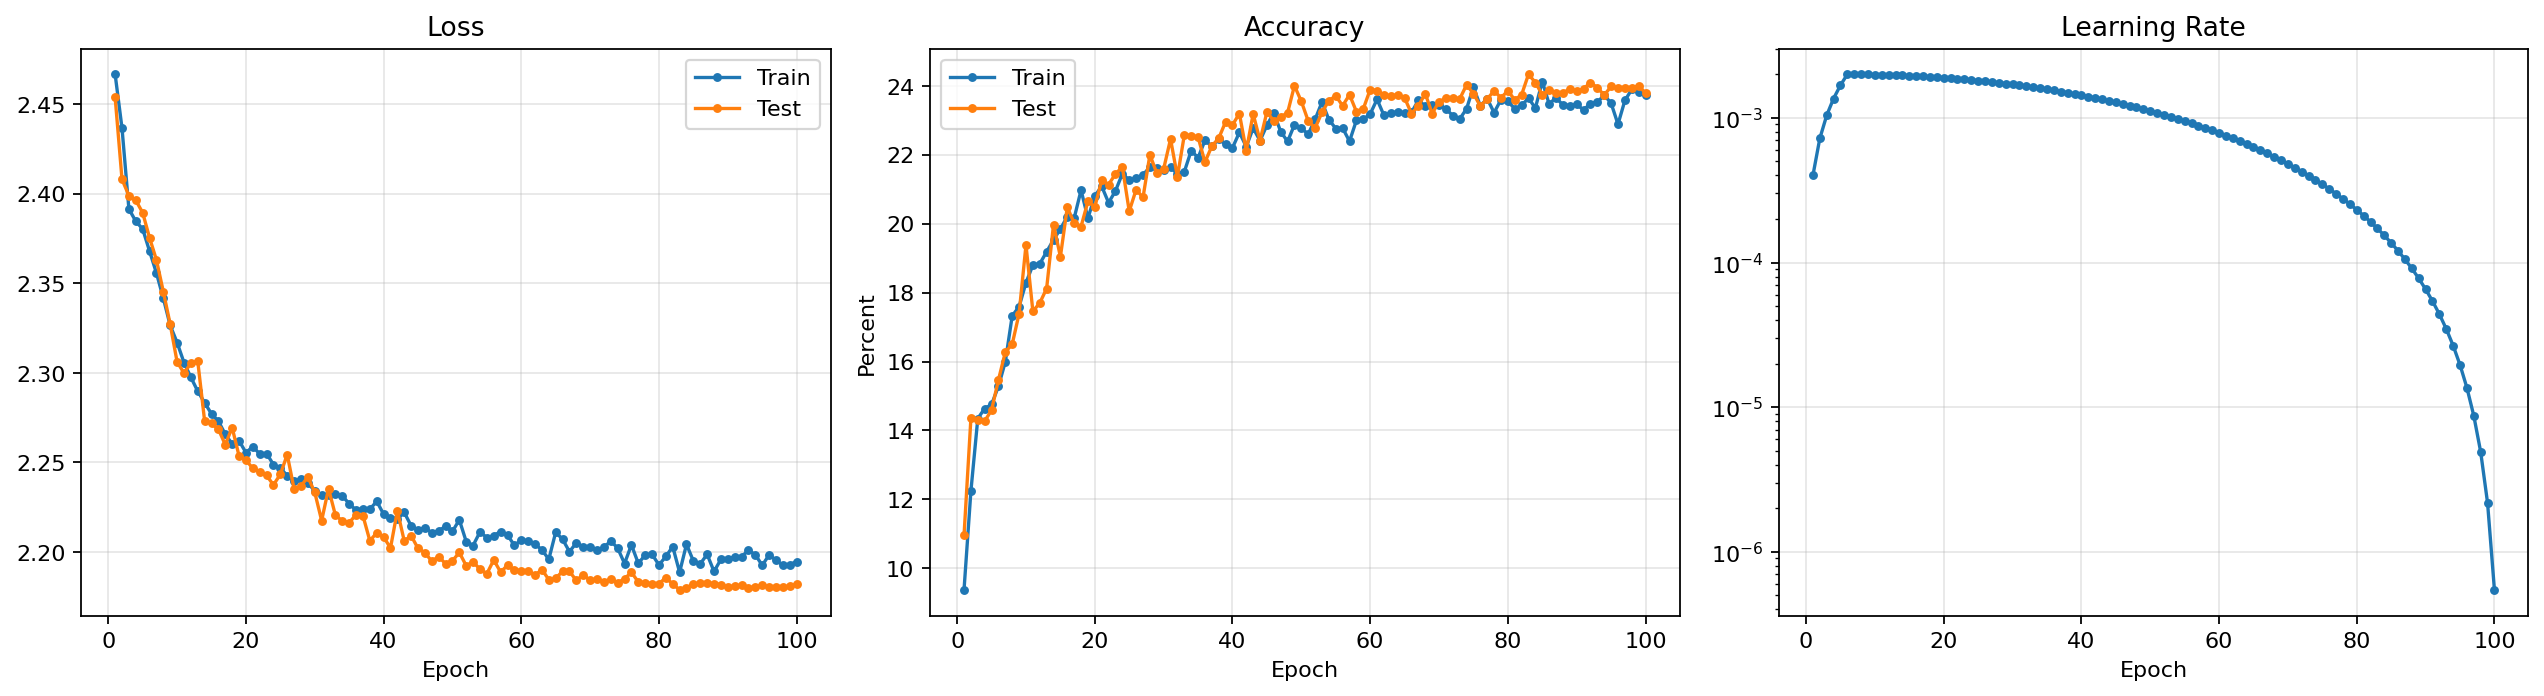

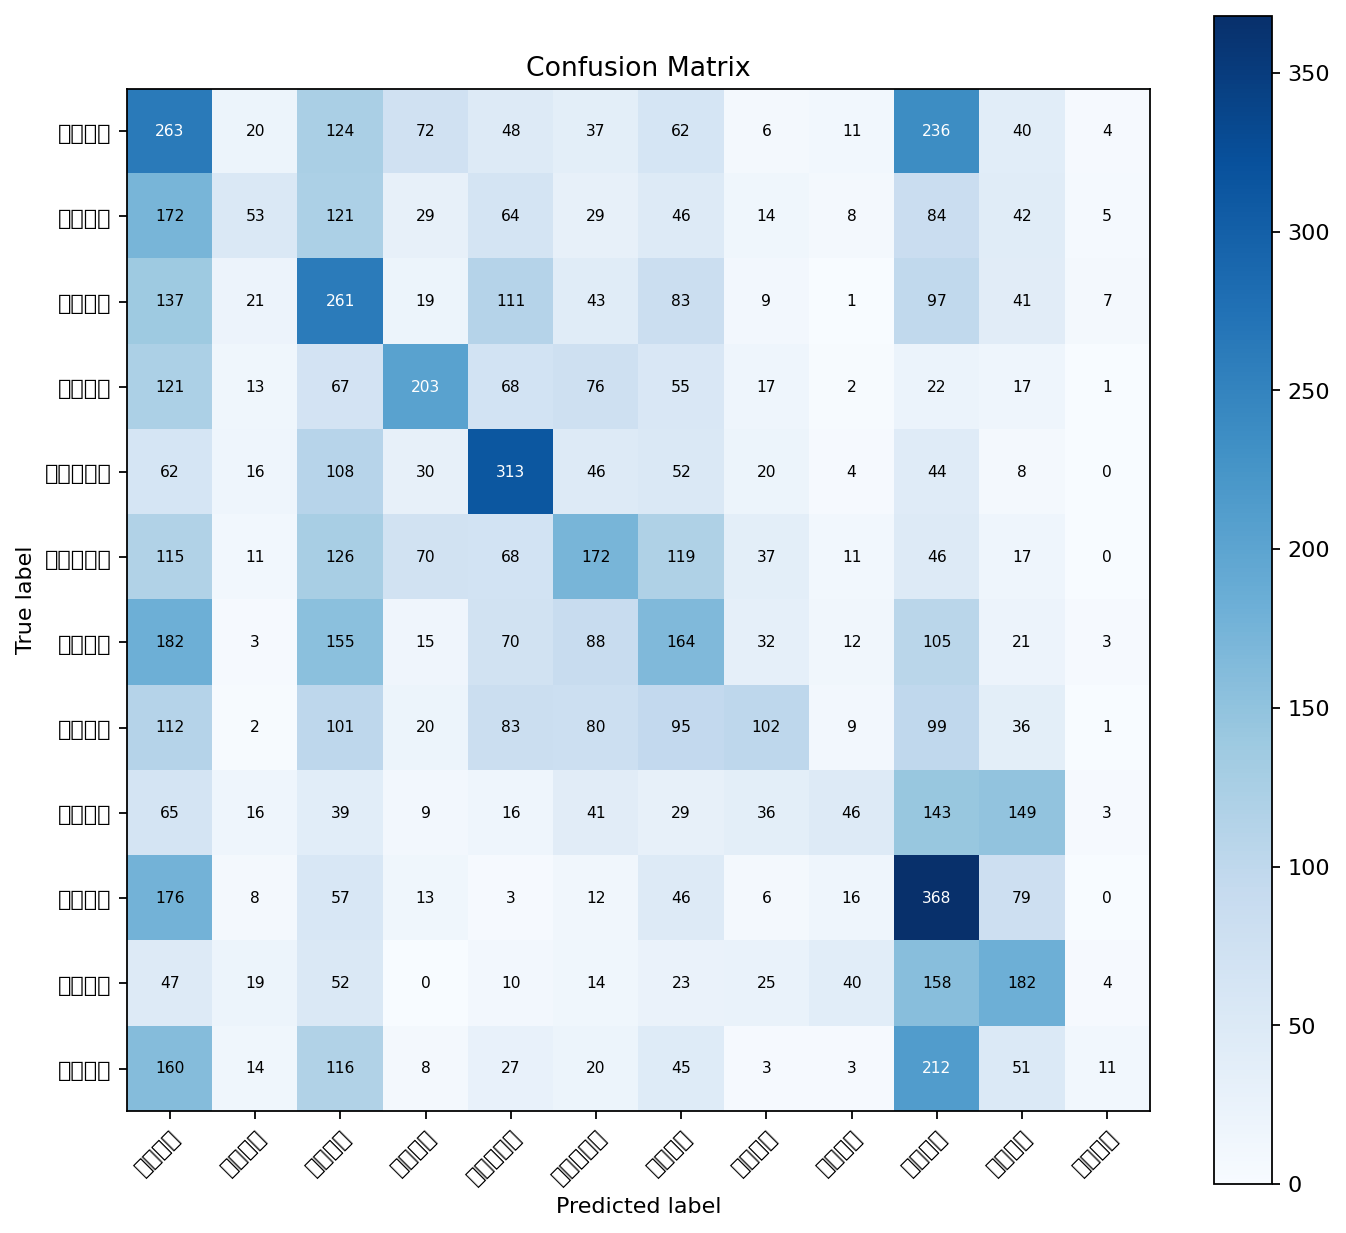

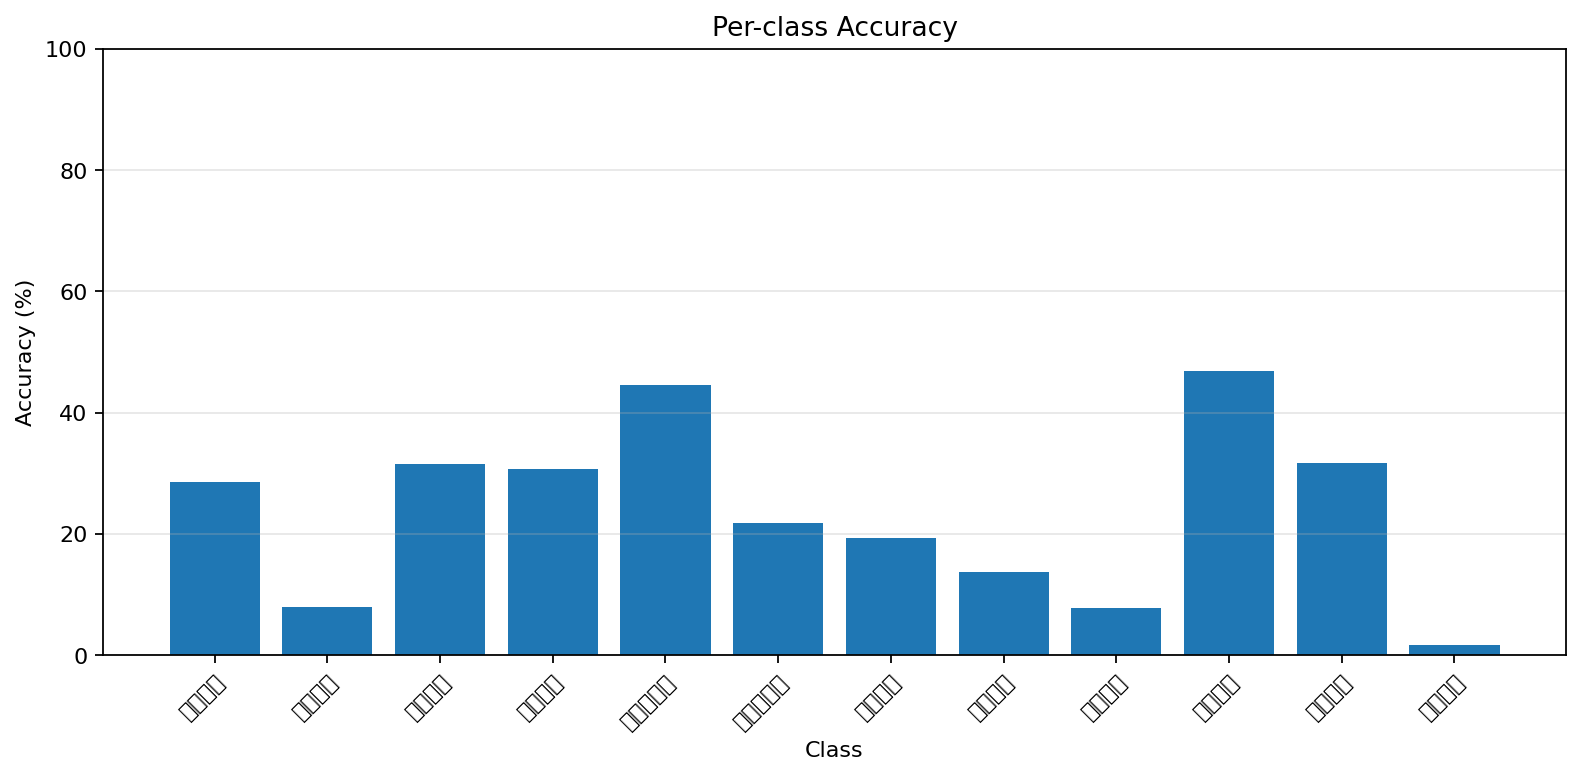

In [10]:
import json
from IPython.display import Image, display

metrics_path = OUTPUT_DIR / "metrics.json"
best_metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
print(f"encoding         = {ENCODING}")
print(f"T                = {T}")
print(f"best epoch       = {best_metrics['best_epoch']}")
print(f"test accuracy    = {best_metrics['accuracy'] * 100:.2f}%")
print(f"macro precision  = {best_metrics['macro_precision'] * 100:.2f}%")
print(f"macro recall     = {best_metrics['macro_recall'] * 100:.2f}%")
print(f"macro F1         = {best_metrics['macro_f1'] * 100:.2f}%")
print("注意：以上结果来自固定泊松测试样本上的 test-selected checkpoint。")

for filename in (
    "training_curves.png",
    "confusion_matrix.png",
    "per_class_accuracy.png",
):
    display(Image(filename=str(OUTPUT_DIR / "figures" / filename)))